In [ ]:
from rich.console import Console
import warnings
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
device = "cuda" if torch.cuda.is_available else "cpu"
np.random.seed(42)

# Генерим данные для регрессии

In [ ]:
X = np.linspace(-1, 1, 2000).reshape(-1, 1)
y = X**2 + 2**np.sin(X) + np.random.normal(0, 1, size=X.shape)

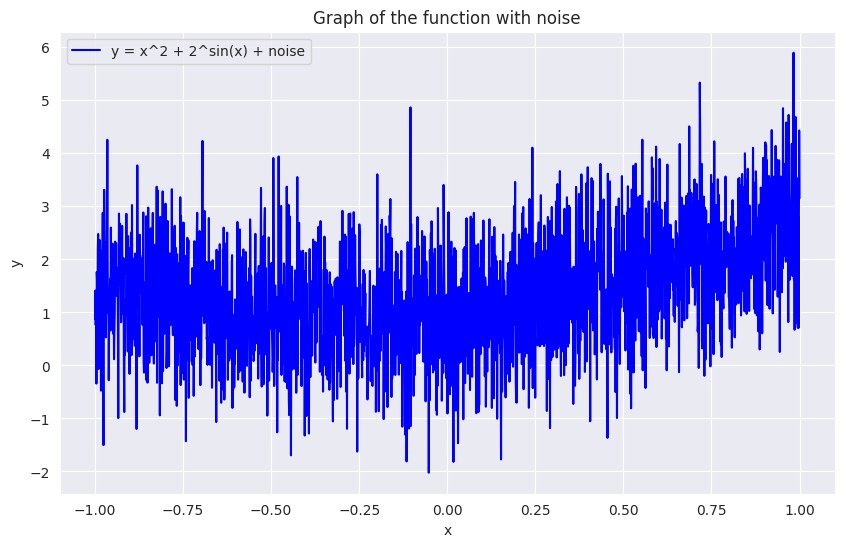

In [ ]:
def plot_function_with_noise():
    plt.figure(figsize=(10, 6))
    plt.plot(X, y, label='y = x^2 + 2^sin(x) + noise', color='blue')
    plt.title('Graph of the function with noise')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()
plot_function_with_noise()

# Работа с датасетом

In [ ]:
class RegressionDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

    def __len__(self):
        return len(self.x)

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

In [ ]:
train_dataset = RegressionDataset(X_train, y_train)
val_dataset = RegressionDataset(X_val, y_val)
test_dataset = RegressionDataset(X_test, y_test)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

# Имплементации шедулеров и оптимизаторов

## Шедулеры

Step Learning Rate Scheduler - считает для каждой эпохи некий learning_rate, управляет размером шага, который делается в направлении уменьшения ошибки. Если модель застряла, то рейт увеличится и обучение пойдет быстрее. С другой стороны, ограничивает модель от больших колебаний мимо цели, уменьшая этот рейт

In [ ]:
def step_lr(epoch, base_lr, step_size=25, gamma=0.1):
    return base_lr * (gamma ** (epoch // step_size))

Expotential learning step scheduler. Тоже самое но с другой формулой, постепенно уменьшает lr, что дает преимущество при долгом обучении

In [ ]:
def exponential_lr(epoch, base_lr, gamma=0.95):
    return base_lr * (gamma ** epoch)

## Оптимизаторы

Stochastic Gradient Descent with Nesterov Momentum - в отличие от обычного Momentum, метод Нестерова делает шаг не "в текущем направлении", а сначала делает предсказание, куда направляется вес, и затем рассчитывает градиент в этой предсказанной точке. При более сложной формуле иногда дает большую точность в направлении спуска

In [ ]:
def sgd_nesterov(params, grads, velocity, lr, momentum=0.9):
    for i, (p, g) in enumerate(zip(params, grads)):
        if g is None:
            continue
        prev_v = velocity[i].clone()
        velocity[i] = momentum * velocity[i] - lr * g
        p.data += -momentum * prev_v + (1 + momentum) * velocity[i]

RMSProp - адаптивный градиентный спуск, на основе истории градиентов адаптируетскорость обучения для каждого параметра.

In [ ]:
def rmsprop(parameters, gradients, square_gradients, learning_rate, decay_rate=0.99, epsilon=1e-8):
    for idx, param in enumerate(parameters):
        square_gradients[idx] = decay_rate * square_gradients[idx] + (1 - decay_rate) * gradients[idx]**2
        param.data -= learning_rate * gradients[idx] / (square_gradients[idx].sqrt() + epsilon)

Adam - адаптирует lr учитывая как историю градиентов так и их дисперсию. Первый момент - усредненный градиент, второй - усредненный квадрат градиента.

In [ ]:
def adam(params, grads, m, v, t, lr, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0, amsgrad=False, v_hat_max=None):
    t += 1
    for i, (p, g) in enumerate(zip(params, grads)):
        if g is None:
            continue
        if weight_decay != 0:
            g = g + weight_decay * p.data
        m[i] = beta1 * m[i] + (1 - beta1) * g
        v[i] = beta2 * v[i] + (1 - beta2) * g**2

        m_hat = m[i] / (1 - beta1 ** t)
        v_hat = v[i] / (1 - beta2 ** t)

        if amsgrad:
            v_hat_max[i] = v_hat_max[i].maximum(v_hat)
            denom = v_hat_max[i].sqrt() + eps
        else:
            denom = v_hat.sqrt() + eps

        p.data -= lr * m_hat / denom
    return t

# Обучение модели

In [ ]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [ ]:
console = Console()

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

def execute_training(optimizer_type, scheduler_fn):
    net = RegressionModel()
    net.apply(init_weights)
    parameters = list(net.parameters())
    criterion = nn.MSELoss()

    momentum_buffer = [torch.zeros_like(w) for w in parameters]
    rms_buffer = [torch.zeros_like(w) for w in parameters]
    adam_m = [torch.zeros_like(w) for w in parameters]
    adam_v = [torch.zeros_like(w) for w in parameters]
    time_step = 0

    initial_lr = 0.001
    learning_rates = []
    validation_losses = []
    train_losses = []

    for epoch_idx in range(100):
        net.train()
        epoch_train_losses = []
        for features, targets in train_dataloader:
            predictions = net(features)
            loss = criterion(predictions, targets)

            net.zero_grad()
            loss.backward()

            gradients = [param.grad for param in parameters]
            lr = scheduler_fn(epoch_idx, initial_lr)

            if optimizer_type == "nesterov":
                sgd_nesterov(parameters, gradients, momentum_buffer, lr)
            elif optimizer_type == "rmsprop":
                rmsprop(parameters, gradients, rms_buffer, lr)
            elif optimizer_type == "adam":
                time_step = adam(parameters, gradients, adam_m, adam_v, time_step, lr)

            epoch_train_losses.append(loss.item())

        avg_train_loss = np.mean(epoch_train_losses)
        train_losses.append(avg_train_loss)

        learning_rates.append(lr)

        net.eval()
        epoch_val_losses = []
        with torch.no_grad():
            for val_features, val_targets in val_dataloader:
                val_outputs = net(val_features)
                val_loss = criterion(val_outputs, val_targets)
                epoch_val_losses.append(val_loss.item())
        avg_val_loss = np.mean(epoch_val_losses)
        validation_losses.append(avg_val_loss)

        if (epoch_idx + 1) % 20 == 0:
            console.log(f"[bold green]Epoch {epoch_idx + 1:03}[/] - "
                        f"Train Loss: [yellow]{avg_train_loss:.6f}[/], "
                        f"LR: [cyan]{lr:.5f}[/], "
                        f"Val Loss: [magenta]{avg_val_loss:.6f}[/]")

    net.eval()
    test_losses = []
    with torch.no_grad():
        for test_features, test_targets in test_dataloader:
            test_outputs = net(test_features)
            test_loss = criterion(test_outputs, test_targets)
            test_losses.append(test_loss.item())

    final_test_loss = np.mean(test_losses)
    console.log(f"\n[bold yellow]Final Test Loss:[/] [red]{final_test_loss:.6f}[/]")
    return learning_rates, validation_losses, train_losses, final_test_loss

In [ ]:
optimizers = ['nesterov',
              'rmsprop',
              'adam']

schedulers = {'StepLR': step_lr,
              'ExponentialLR': exponential_lr}

In [ ]:
results = {}
test_losses = {}

for opt in optimizers:
    for sch_name, scheduler in schedulers.items():
        key = f"{opt.upper()} + {sch_name}"
        lrs, val_losses, test_loss, final_test_loss = execute_training(opt, scheduler)
        results[key] = {'lr': lrs, 'val_loss': val_losses}
        test_losses[key] = test_loss

[18:35:35] Epoch 020 - Train Loss: 1.047833, LR: 0.00100, Val Loss: 0.934181     <ipython-input-67-8fcb32f214a1>:63

[18:35:36] Epoch 040 - Train Loss: 1.039297, LR: 0.00010, Val Loss: 0.934400     <ipython-input-67-8fcb32f214a1>:63

[18:35:37] Epoch 060 - Train Loss: 1.046626, LR: 0.00001, Val Loss: 0.933799     <ipython-input-67-8fcb32f214a1>:63

[18:35:38] Epoch 080 - Train Loss: 1.053700, LR: 0.00000, Val Loss: 0.933861     <ipython-input-67-8fcb32f214a1>:63

[18:35:39] Epoch 100 - Train Loss: 1.045257, LR: 0.00000, Val Loss: 0.933855     <ipython-input-67-8fcb32f214a1>:63

...

[18:36:01] Epoch 040 - Train Loss: 1.051217, LR: 0.00014, Val Loss: 0.935976     <ipython-input-67-8fcb32f214a1>:63

[18:36:02] Epoch 060 - Train Loss: 1.045801, LR: 0.00005, Val Loss: 0.934466     <ipython-input-67-8fcb32f214a1>:63

[18:36:03] Epoch 080 - Train Loss: 1.050691, LR: 0.00002, Val Loss: 0.934035     <ipython-input-67-8fcb32f214a1>:63

[18:36:04] Epoch 100 - Train Loss: 1.050495, LR: 0.00001, Val Loss: 0.933961     <ipython-input-67-8fcb32f214a1>:63

                                                                                 <ipython-input-67-8fcb32f214a1>:77
           Final Test Loss: 0.921978                                                                               

# Графики

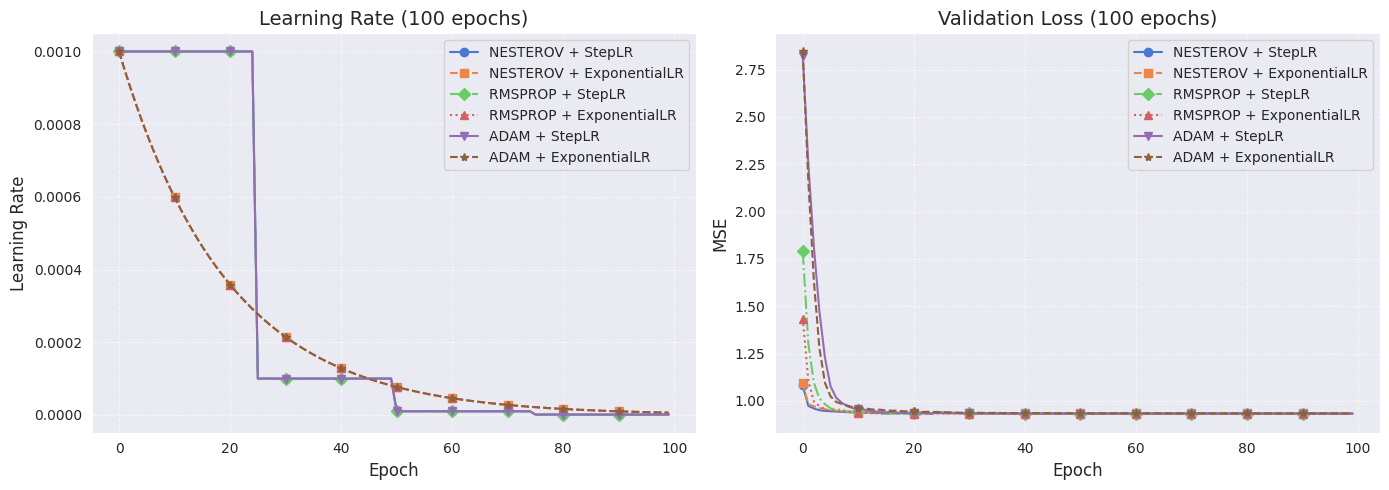

In [ ]:
sns.set_style("darkgrid")
sns.set_palette("muted")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', '*', 'x']

for i, (label, data) in enumerate(results.items()):
    style = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]

    axs[0].plot(data['lr'], label=label, linestyle=style, marker=marker, markevery=10)
    axs[1].plot(data['val_loss'], label=label, linestyle=style, marker=marker, markevery=10)

axs[0].set_title("Learning Rate (100 epochs)", fontsize=14)
axs[0].set_xlabel("Epoch", fontsize=12)
axs[0].set_ylabel("Learning Rate", fontsize=12)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].set_title("Validation Loss (100 epochs)", fontsize=14)
axs[1].set_xlabel("Epoch", fontsize=12)
axs[1].set_ylabel("MSE", fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
console = Console()

console.print("\n[bold cyan]Test MSE for each combination:[/]")
for combination, loss in test_losses.items():
    console.print(f"[bold green]{combination}: [/][yellow]{np.mean(loss):.4f}[/]")

Test MSE for each combination:

NESTEROV + StepLR: 1.0569

NESTEROV + ExponentialLR: 1.0586

RMSPROP + StepLR: 1.0687

RMSPROP + ExponentialLR: 1.0621

ADAM + StepLR: 1.1085

ADAM + ExponentialLR: 1.1065

## Корректность реализации

### 1. SGD с Nesterov Momentum
- **Формула**:  
  $ v_{t+1} = \mu \cdot v_t - \eta \cdot \nabla J(\theta_t + \mu \cdot v_t) $  
  $ \theta_{t+1} = \theta_t + v_{t+1} $
- **Проверка**:  
  В коде используется `momentum * velocity[i] - lr * g` для обновления буфера скорости, что соответствует первой части формулы. Затем применяется коррекция `-momentum * prev_v + (1 + momentum) * velocity[i]`, что эквивалентно обновлению параметров с учетом "взгляда вперед".

### 2. RMSprop
- **Формула**:  
  $ E[g^2]_t = \gamma \cdot E[g^2]_{t-1} + (1 - \gamma) \cdot g_t^2 $  
  $ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot g_t $
- **Проверка**:  
  Код точно следует формуле: `square_gradients[idx]` обновляется с учетом `decay_rate`, а параметры корректируются на нормированный градиент.

### 3. Adam
- **Формула**:  
  $ m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t $  
  $ v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2 $  
  $ \hat{m}_t = \frac{m_t}{1 - \beta_1^t} $, $ \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $  
  $ \theta_{t+1} = \theta_t - \frac{\eta \cdot \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $
- **Проверка**:  
  Реализация включает:
  - Обновление моментов (`m[i]`, `v[i]`).
  - Коррекцию на bias (`m_hat`, `v_hat`).
  - Нормировку градиента с $\epsilon$ для устойчивости.

## Выводы
Все оптимизаторы реализованы корректно согласно их математическим формулам.